#**01. Machine Learning aplicado a bienes raices: Algoritmo K-vecinos más cercanos**

##**Modelo de Predicción de Precios de Terrenos**

Este modelo de aprendizaje supervisado permite estimar de manera precisa el valor de terrenos en las zonas de Lima Norte, cercanas al futuro centro logístico que representará el mega puerto de Chancay. Con un crecimiento económico proyectado y una alta demanda por terrenos, esta herramienta brinda información clave para inversionistas interesados en esta área de alto potencial.

Para la construcción del modelo se desarrolla los siguientes pasos:

##**Paso 1: Objetivo del Modelo:**

El objetivo principal es desarrollar un modelo predictivo que, al ser entrenado con datos reales de terrenos, pueda proyectar el precio de terrenos en base a características fundamentales.

##**Paso 2: Recolectar y limpiar los datos**

**Recolecta los datos**: Obtén un conjunto de datos de bienes raíces. Puede ser de fuentes locales, llamadas por telefonos, paginas web o recolectar directamente de lugar de ventas.

**Explora los datos**: Carga los datos en un DataFrame de pandas para analizar su contenido.

**Limpieza de datos**:

*  Maneja valores nulos o faltantes (NaN).

*  Identifica y elimina duplicados.

*  Trata valores atípicos (outliers) si es necesario.

*  Convierte variables categóricas (como el tipo de propiedad) a variables numéricas usando técnicas como One-Hot Encoding.

##**Paso 3: Análisis exploratorio de datos (EDA)**

Realiza un análisis exploratorio para entender la distribución de las variables y las relaciones entre ellas.

**Estadísticas descriptivas**:

data.describe()

**Visualización de correlaciones**: Utiliza un mapa de calor para ver cómo se correlacionan las variables. Esto puede ayudar a identificar características relevantes para la predicción.

**Visualización de variables clave**: Examina la relación entre variables como el tamaño de la propiedad o la ubicación y el precio.

##**Paso 4: Selección de características (Feature Selection)**

Para reducir la complejidad del modelo, selecciona solo las características más relevantes.

**Eliminar características irrelevantes**: Quita columnas que no contribuyan significativamente a la predicción, como ID o timestamp.

**Métodos de selección**: Puedes usar métodos estadísticos o de correlación para identificar características relevantes.

##**Paso 5: Dividir los datos en conjunto de entrenamiento y prueba**

**Divide los datos en dos partes**: conjunto de entrenamiento y conjunto de prueba. Esto permite evaluar el modelo de forma justa.

##**Paso 6: Selección del modelo**

Para predecir precios, se suelen usar modelos de regresión. Algunos modelos comunes son:

**Regresión lineal**: Bueno para comenzar y entender relaciones lineales.

**Vecinos más Cercanos**: algoritmo para realizar predicción y clasificación

**Máquina de Soporte Vectorial**: Para regresión y clasificación

**Árboles de decisión**: Pueden capturar relaciones no lineales.

**Random Forest y Gradient Boosting**: Modelos avanzados que suelen mejorar la precisión.

##**Paso 7: Entrenamiento del modelo**

Elige un modelo, ajústalo a los datos de entrenamiento y evalúa su desempeño en el conjunto de prueba.

##**Paso 8: Evaluación del modelo**

Evalúa el modelo en los datos de prueba usando métricas de regresión.

Evaluación en datos de prueba:


Interpretación:

**MAE (Error Absoluto Medio)**: Promedio de los errores absolutos.

**MSE (Error Cuadrático Medio)**: Penaliza más los errores grandes.

**R² (Coeficiente de Determinación)**: Indica qué tan bien se ajusta el modelo a los datos (más cercano a 1 es mejor).


##**Paso 9: Optimización del modelo**

Prueba diferentes parámetros o técnicas para mejorar el modelo.

**Ajuste de hiperparámetros**: Utiliza GridSearchCV para encontrar la combinación óptima de parámetros.

**Ajuste de características**: Intenta reducir o cambiar las características de entrada según la importancia que asigna el modelo a cada una.

##**Paso 10: Implementación y pruebas finales**

Guarda el modelo entrenado y evalúa su rendimiento en datos adicionales.

Los datos contienen las siguientes columnas:


**Área (m²)**: Superficie total del terreno en metros cuadrados.

**Topografía**: Clasificación de la pendiente del terreno en cinco categorías: (1) Pendiente pronunciada, (2) Pendiente ondulada, (3) Llanura, (4) Zona baja, y (5) Zona elevada.

**Forma del Terreno**: Clasificación en siete tipos: (1) Irregular, (2) Cuadrado, (3) Forma de escalera, (4) Triangular, (5) Forma de bandera, (6) Rectángulo vertical, y (7) Rectángulo horizontal.

**Camino Contiguo**: Tipo de acceso al terreno, clasificado en: (1) Panamericana, (2) Vía pública, (3) Carretera mediana, (4) Camino medio estrecho, y (5) Sin acceso por carretera.

**Acceso a Servicios**: Disponibilidad de servicios básicos: (1) Agua (sí/no), (2) Luz (sí/no), y (3) Alcantarillado (sí/no).

**Distancia a Pista de Doble Vía**: Distancia en kilómetros desde el terreno hasta una pista de doble vía.

**Documento de Propiedad**: Tipo de documento de propiedad registrado: (1) Título de propiedad, (2) Partida registral, (3) Licencia de uso, (4) Contrato de compra y venta, (5) Autovalúo, y (6) Acciones y derechos.

**Zonificación**: Uso asignado del terreno: (1) Residencial, (2) Comercial, (3) Industrial, (4) Recreativa, y (5) Rural.

**Tipo de Suelo**: Clasificación del suelo en dos tipos: (1) Rocoso y (2) Arenoso.

**Vista**: Existencia de vista panorámica (1: Sí, 2: No).

**Ciudad**: Localización del terreno en una de las ciudades estudiadas: (1) Huaral, (2) Huaura, (3) Barranca, y (4) Huacho.

**Promedio de Ingresos del Área**: Ingreso promedio de los residentes de la ciudad.

**Población del Área**: Tamaño poblacional de la ciudad.

**Dimensión largo**: Medidas específicas del terreno, registradas como Largo.

**Dimensión ancho**: Medidas específicas del terreno, registradas como Ancho.

**Precio(m²)**: Valor del terreno expresado en dólares estadounidenses.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/basedatos/BasedeDatosDefinitiva.csv')
data

,area,topografia,forma,cam_conti,agua,luz,alcantarillado,dist_pist(Km),tip_doc,zonificación,tip_suelo,largo(mts),ancho(mts),vist_pano,población,ciudad,precio,precio(mts2)
0,108,llanura,horizontal,camino_medio_estrecho,si,si,si,1,titulo,residencial,rocoso,18.00,6.00,no,32312,Chancay,30000,277.777778
1,112,llanura,vertical,via_publica,si,si,si,2,titulo,residencial,rocoso,14.00,8.00,no,29671,Hualmay,30000,285.714286
2,120,llanura,vertical,camino_medio_estrecho,si,si,si,1,titulo,residencial,rocoso,15.00,8.00,si,156326,Barranca,35000,291.666667
3,121,llanura,horizontal,camino_medio_estrecho,si,si,si,0,titulo,residencial,rocoso,11.27,10.75,no,37121,Huaura,37000,305.785124
4,125,llanura,vertical,camino_medio_estrecho,si,si,si,1,titulo,residencial,rocoso,15.00,8.30,si,156326,Barranca,40000,320.000000
5,125,llanura,horizontal,camino_medio_estrecho,si,si,si,0,titulo,residencial,rocoso,18.27,6.86,no,37121,Huaura,42000,336.000000
6,126,llanura,horizontal,camino_medio_estrecho,si,si,si,0,titulo,residencial,rocoso,12.00,10.50,no,37121,Huaura,38000,301.587302
7,130,llanura,horizontal,camino_medio_estrecho,si,si,si,1,titulo,residencial,rocoso,11.82,11.00,no,37121,Huaura,42000,323.076923
8,156,llanura,vertical,camino_medio_estrecho,si,si,si,1,titulo,residencial,rocoso,14.20,11.00,no,37121,Huaura,50000,320.512820
9,165,llanura,vertical,via_publica,si,si,si,2,titulo,residencial,rocoso,17.00,9.70,si,29671,Hualmay,54000,327.272727


##**info()**

El método data.info() se utiliza en Python, específicamente con DataFrames de la biblioteca pandas, para proporcionar un resumen conciso de la estructura del DataFrame. Es muy útil para obtener una vista general de los datos.

Información que proporciona:

*  Nombre del índice: Si el DataFrame tiene un índice personalizado.
*  Cantidad de filas y columnas: Da el número total de entradas (filas) y columnas.
*  Nombre de las columnas: Lista los nombres de todas las columnas.
*  Número de valores no nulos por columna: Muestra cuántos valores no nulos hay en cada columna.
*  Tipo de dato de cada columna: Indica el tipo de dato de cada columna (int64, float64, object, etc.).
*  Uso de memoria: Muestra el uso aproximado de memoria del DataFrame.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            34 non-null     int64  
 1   topografia      34 non-null     object 
 2   forma           34 non-null     object 
 3   cam_conti       34 non-null     object 
 4   agua            34 non-null     object 
 5   luz             34 non-null     object 
 6   alcantarillado  34 non-null     object 
 7   dist_pist(Km)   34 non-null     int64  
 8   tip_doc         34 non-null     object 
 9   zonificación    34 non-null     object 
 10  tip_suelo       34 non-null     object 
 11  largo(mts)      34 non-null     float64
 12  ancho(mts)      34 non-null     float64
 13  vist_pano       34 non-null     object 
 14  población       34 non-null     int64  
 15  ciudad          34 non-null     object 
 16  precio          34 non-null     int64  
 17  precio(mts2)    34 non-null     float

###**describe()**

El método data.describe() en pandas proporciona estadísticas descriptivas resumidas de un conjunto de datos. Es útil para obtener una visión general rápida de los datos numéricos (o categóricos, si se especifica) en un DataFrame o una Serie.

In [ ]:
data.describe()

,area,dist_pist(Km),largo(mts),ancho(mts),población,precio,precio(mts2)
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,642.823529,1.411765,27.138824,18.086176,51191.352941,134997.058824,271.603437
std,854.487033,0.957194,15.910087,12.204543,43547.938967,160395.833251,65.000124
min,108.000000,0.000000,11.270000,6.000000,22080.000000,30000.000000,112.231183
25%,158.250000,1.000000,16.467500,10.562500,32312.000000,51000.000000,260.424710
50%,248.500000,1.000000,19.530000,14.000000,37121.000000,75000.000000,290.994624
75%,663.750000,2.000000,35.000000,21.875000,38678.000000,173750.000000,319.904306
max,4264.000000,3.000000,68.000000,65.600000,171070.000000,950000.000000,336.000000


##**columns()**

El atributo data.columns en pandas devuelve un objeto Index que contiene los nombres de las columnas de un DataFrame. Esto es útil para consultar o manipular las etiquetas de las columnas de tu DataFrame.

In [ ]:
data.columns

Index(['area', 'topografia', 'forma', 'cam_conti', 'agua', 'luz',
       'alcantarillado', 'dist_pist(Km)', 'tip_doc', 'zonificación',
       'tip_suelo', 'largo(mts)', 'ancho(mts)', 'vist_pano', 'población',
       'ciudad', 'precio', 'precio(mts2)'],
      dtype='object')

Visualiza la columna precio de terreno

In [ ]:
data['precio(mts2)']

,precio(mts2)
0,277.777778
1,285.714286
2,291.666667
3,305.785124
4,320.000000
5,336.000000
6,301.587302
7,323.076923
8,320.512820
9,327.272727


El comando sns.**distplot(data['precio(mts2)'])** utiliza Seaborn, una biblioteca de visualización en Python, para crear un gráfico de distribución que combina un histograma con una curva de densidad (KDE, Kernel Density Estimate). Esto permite visualizar cómo se distribuyen los valores de la columna precio(mts2) en el conjunto de datos.



<ipython-input-8-745c5d20754f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['precio(mts2)'])


<Axes: xlabel='precio(mts2)', ylabel='Density'>

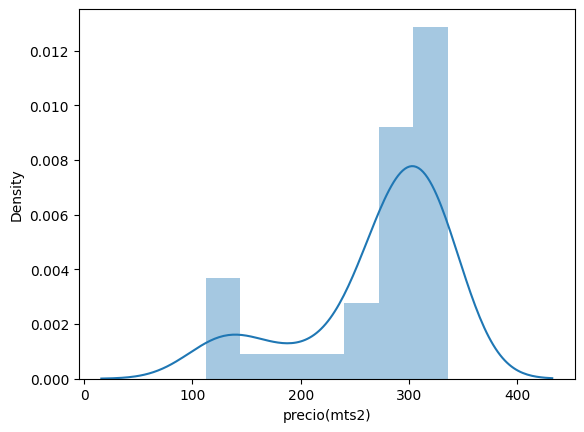

In [ ]:
sns.distplot(data['precio(mts2)'])

##**Correlación**

Creamos un mapa de calor que muestra la matriz de correlación entre las columnas seleccionadas: area, largo(mts), ancho(mts) y población. Este gráfico es útil para visualizar rápidamente las relaciones entre estas variables numéricas.



<Axes: >

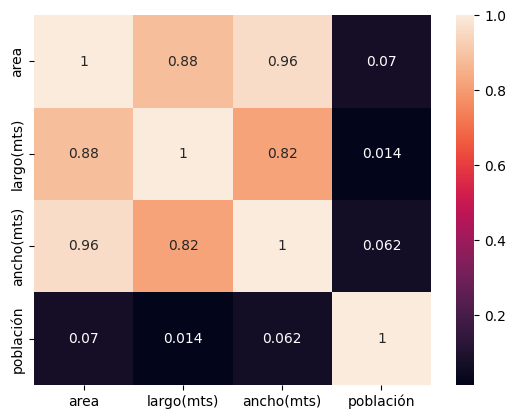

In [ ]:
sns.heatmap(data.loc[:,['area','largo(mts)','ancho(mts)','población']].corr(),annot=True)

Dataframe con variables solo numéricos

In [ ]:
datanum=data.loc[:,['area','largo(mts)','ancho(mts)','población']]

In [ ]:
dataprecio=data['precio']
dataprecio

,precio
0,30000
1,30000
2,35000
3,37000
4,40000
5,42000
6,38000
7,42000
8,50000
9,54000


##**Damificando varoables**

DataFrame con variables solo categóricos

In [ ]:
datadamy=data[['topografia', 'forma', 'cam_conti', 'agua', 'luz',
       'alcantarillado', 'tip_doc', 'zonificación',
       'tip_suelo', 'vist_pano',
       'ciudad',]]
datadamy

,topografia,forma,cam_conti,agua,luz,alcantarillado,tip_doc,zonificación,tip_suelo,vist_pano,ciudad
0,llanura,horizontal,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Chancay
1,llanura,vertical,via_publica,si,si,si,titulo,residencial,rocoso,no,Hualmay
2,llanura,vertical,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,si,Barranca
3,llanura,horizontal,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Huaura
4,llanura,vertical,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,si,Barranca
5,llanura,horizontal,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Huaura
6,llanura,horizontal,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Huaura
7,llanura,horizontal,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Huaura
8,llanura,vertical,camino_medio_estrecho,si,si,si,titulo,residencial,rocoso,no,Huaura
9,llanura,vertical,via_publica,si,si,si,titulo,residencial,rocoso,si,Hualmay


In [ ]:
datanum=data[['area','dist_pist(Km)','largo(mts)','ancho(mts)','población']]
datanum

,area,dist_pist(Km),largo(mts),ancho(mts),población
0,108,1,18.00,6.00,32312
1,112,2,14.00,8.00,29671
2,120,1,15.00,8.00,156326
3,121,0,11.27,10.75,37121
4,125,1,15.00,8.30,156326
5,125,0,18.27,6.86,37121
6,126,0,12.00,10.50,37121
7,130,1,11.82,11.00,37121
8,156,1,14.20,11.00,37121
9,165,2,17.00,9.70,29671


##**Escalando o Normalizar las variables**

Este código normaliza los datos numéricos contenidos en el DataFrame datanum utilizando la técnica de estandarización. La estandarización transforma los datos para que tengan una media de 0 y una desviación estándar de 1, lo cual es útil para algoritmos de aprendizaje automático sensibles a las escalas de las variables, como SVM, k-means y PCA.

In [ ]:

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
datastand = sc_X.fit_transform(datanum)
datastand=pd.DataFrame(datastand,columns=datanum.columns)
datastand

,area,dist_pist(Km),largo(mts),ancho(mts),población
0,-0.635313,-0.436648,-0.583042,-1.005194,-0.440050
1,-0.630561,0.623783,-0.838236,-0.838856,-0.501608
2,-0.621058,-0.436648,-0.774438,-0.838856,2.450534
3,-0.619870,-1.497079,-1.012406,-0.610142,-0.327959
4,-0.615119,-0.436648,-0.774438,-0.813906,2.450534
5,-0.615119,-1.497079,-0.565817,-0.933669,-0.327959
6,-0.613931,-1.497079,-0.965833,-0.630934,-0.327959
7,-0.609179,-0.436648,-0.977317,-0.589349,-0.327959
8,-0.578294,-0.436648,-0.825476,-0.589349,-0.327959
9,-0.567603,0.623783,-0.646841,-0.697469,-0.501608


##**Variable Dummy**

Este código convierte las columnas categóricas en variables dummy (también conocidas como variables indicadoras) y las incorpora a un DataFrame que combina tanto los datos estandarizados como las variables dummy y, opcionalmente, una columna adicional (dataprecio). Vamos a analizar cada paso:

In [ ]:
# Selección de las columnas categóricas
categorical_columns = ['topografia', 'forma', 'cam_conti', 'agua', 'luz',
                       'alcantarillado', 'tip_doc', 'zonificación',
                       'tip_suelo', 'vist_pano', 'ciudad']

# Generar variables dummy
data_dummies = pd.get_dummies(data[categorical_columns], drop_first=True)

# Unir las variables dummy al DataFrame original (opcional)
data_with_dummies = pd.concat([datastand,data_dummies,dataprecio], axis=1)

# Ver las primeras filas del nuevo DataFrame
print(data_with_dummies.head())

       area  dist_pist(Km)  largo(mts)  ancho(mts)  población  forma_vertical  \
0 -0.635313      -0.436648   -0.583042   -1.005194  -0.440050           False   
1 -0.630561       0.623783   -0.838236   -0.838856  -0.501608            True   
2 -0.621058      -0.436648   -0.774438   -0.838856   2.450534            True   
3 -0.619870      -1.497079   -1.012406   -0.610142  -0.327959           False   
4 -0.615119      -0.436648   -0.774438   -0.813906   2.450534            True   

   cam_conti_via_publica  agua_si  luz_si  alcantarillado_no  ...  \
0                  False     True    True              False  ...   
1                   True     True    True              False  ...   
2                  False     True    True              False  ...   
3                  False     True    True              False  ...   
4                  False     True    True              False  ...   

   tip_suelo_rocoso  vist_pano_si  ciudad_Chancay  ciudad_Huacho  \
0              True         Fa

##**Construcción del Modelo Machine Learning**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

El siguiente código separa el conjunto de datos data_with_dummies en variables predictoras (X) y variable objetivo (y) utilizando indexación por posición con iloc. Esto es un paso fundamental en la preparación de datos para entrenamiento de modelos de aprendizaje automático.

In [ ]:
X=data_with_dummies.iloc[:,:-1]
y=data_with_dummies.iloc[:,-1]

El siguiente código divide el conjunto de datos en dos subconjuntos: uno para entrenamiento y otro para prueba, utilizando la función train_test_split de la biblioteca Scikit-learn. Esto es un paso esencial para evaluar el desempeño de un modelo de aprendizaje automático, asegurándose de que se entrena y evalúa en datos diferentes

In [ ]:
X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
X_train

,area,dist_pist(Km),largo(mts),ancho(mts),población,forma_vertical,cam_conti_via_publica,agua_si,luz_si,alcantarillado_no,...,zonificación_residencial,tip_suelo_rocoso,vist_pano_si,ciudad_Chancay,ciudad_Huacho,ciudad_Hualmay,ciudad_Huaral,ciudad_Huaura,ciudad_Santa_maria,ciudad_Vegueta
4,-0.615119,-0.436648,-0.774438,-0.813906,2.450534,True,False,True,True,False,...,True,True,True,False,False,False,False,False,False,False
16,-0.490390,1.684214,-0.685120,-0.339843,-0.291668,False,True,True,True,False,...,True,True,True,False,False,False,False,False,True,False
17,-0.446438,-1.497079,-0.391647,-0.447962,-0.291668,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
5,-0.615119,-1.497079,-0.565817,-0.933669,-0.327959,False,False,True,True,False,...,True,True,False,False,False,False,False,True,False,False
13,-0.522463,1.684214,-0.804423,-0.339843,-0.291668,False,True,True,True,False,...,True,True,True,False,False,False,False,False,True,False
11,-0.537906,-0.436648,-0.667894,-0.556082,-0.327959,True,False,True,True,False,...,True,True,False,False,False,False,False,True,False,False
1,-0.630561,0.623783,-0.838236,-0.838856,-0.501608,True,True,True,True,False,...,True,True,False,False,False,True,False,False,False,False
2,-0.621058,-0.436648,-0.774438,-0.838856,2.450534,True,False,True,True,False,...,True,True,True,False,False,False,False,False,False,False
30,1.215423,0.623783,2.606878,0.533431,-0.501608,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,-0.619870,-1.497079,-1.012406,-0.610142,-0.327959,False,False,True,True,False,...,True,True,False,False,False,False,False,True,False,False


muestra las dimensiones (filas y columnas) de los conjuntos de prueba X_test (las características) y y_test (la variable objetivo), en forma de tupla.



In [ ]:
X_test.shape,y_test.shape

((11, 21), (11,))

##**Entrenamiento del modelo**

realiza la entrenamiento de un modelo de regresión lineal utilizando los datos de entrenamiento X_train y y_train.

*  LinearRegression(): Este es un objeto de la clase LinearRegression de Scikit-learn, que es utilizado para realizar una regresión lineal. La regresión lineal es un modelo que intenta predecir una variable continua (y) a partir de una o más variables independientes (X).

*  lrm es una instancia de este modelo que se utilizará para ajustar (entrenar) el modelo con los datos.

In [ ]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Lista de modelos a evaluar
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Support Vector Regressor (SVR)": SVR(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# Iterar sobre cada modelo
for name, model in models.items():
    print(f"\nEvaluando modelo: {name}")

    # Entrenar el modelo con los datos de entrenamiento
    model.fit(X_train, y_train)

    # Predecir con los datos de prueba
    predictions = model.predict(X_test)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Mostrar resultados
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"  R² (Coeficiente de Determinación): {r2:.4f}")


Evaluando modelo: Linear Regression
  Mean Absolute Error (MAE): 26768.8797
  Mean Squared Error (MSE): 1741594258.2786
  Root Mean Squared Error (RMSE): 41732.4126
  R² (Coeficiente de Determinación): 0.6362

Evaluando modelo: K-Nearest Neighbors
  Mean Absolute Error (MAE): 33038.1818
  Mean Squared Error (MSE): 2239091818.1818
  Root Mean Squared Error (RMSE): 47319.0429
  R² (Coeficiente de Determinación): 0.5323

Evaluando modelo: Support Vector Regressor (SVR)
  Mean Absolute Error (MAE): 66380.1250
  Mean Squared Error (MSE): 7385963931.1502
  Root Mean Squared Error (RMSE): 85941.6310
  R² (Coeficiente de Determinación): -0.5429

Evaluando modelo: Ridge Regression
  Mean Absolute Error (MAE): 27659.3594
  Mean Squared Error (MSE): 1574586780.5784
  Root Mean Squared Error (RMSE): 39681.0632
  R² (Coeficiente de Determinación): 0.6711

Evaluando modelo: Lasso Regression
  Mean Absolute Error (MAE): 9270.3824
  Mean Squared Error (MSE): 161444442.0819
  Root Mean Squared Error (